Author: Krish

In [1]:
# Importing relevant libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

### User input required
Put the data path on your system in the cell below

In [2]:
data_path = "CAR_-_EP_Flow_Activity_Queue__Agent_Names"

### User input ends

### Reading all filenames in the data folder

In [3]:
folder = Path(data_path)
files = sorted(list(folder.glob("*.csv")) + list(folder.glob("*.xlsx")))
df_main = pd.DataFrame(columns=['Contact Session ID', 'EP Name', 'Flow Name', 'Activity Name', 'Activity Start Timestamp', 
                                'Queue Name', 'Agent Name', 'Termination Reason'])
df_main

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason


### Reading all data files
The code chunk below reads and appends all the CAR data files. The first two rows of each file are blank and thus ignored.

In [4]:
i=0
for f in files:
    i = i + 1
    if f.suffix.lower() == ".csv":
        df = pd.read_csv(f, header=2, dtype=str, engine="python", skip_blank_lines=False)
    else:  # .xlsx
        df = pd.read_excel(f, sheet_name=0, header=2, dtype=str)
    df_main = pd.concat([df_main, df], ignore_index=True)
    print(i, f.stem, df.shape)

1 CAR - EP, Flow, Activity, Queue, & Agent Names (01-12-25 - 01-18-25) (52010, 7)
2 CAR - EP, Flow, Activity, Queue, & Agent Names (01-19-25 - 02-01-25) (95495, 7)
3 CAR - EP, Flow, Activity, Queue, & Agent Names (02-02-25 - 02-15-25) (90056, 7)
4 CAR - EP, Flow, Activity, Queue, & Agent Names (02-16-25 - 03-01-25) (88186, 7)
5 CAR - EP, Flow, Activity, Queue, & Agent Names (03-02-25 - 03-15-25) (86377, 7)
6 CAR - EP, Flow, Activity, Queue, & Agent Names (04-07-24 - 04-20-24) (88766, 7)
7 CAR - EP, Flow, Activity, Queue, & Agent Names (04-21-24 - 05-04-24) (89643, 7)
8 CAR - EP, Flow, Activity, Queue, & Agent Names (05-05-24 - 05-18-24) (82575, 7)
9 CAR - EP, Flow, Activity, Queue, & Agent Names (05-19-24 - 06-01-24) (71103, 7)
10 CAR - EP, Flow, Activity, Queue, & Agent Names (06-02-24 - 06-15-24) (84354, 7)
11 CAR - EP, Flow, Activity, Queue, & Agent Names (06-16-24 - 06-29-24) (82124, 7)
12 CAR - EP, Flow, Activity, Queue, & Agent Names (06-30-24 - 07-13-24) (79752, 7)
13 CAR - EP, 

### Time datatype conversion
The code chunk below converts time from string to datetime datatype.

In [5]:
df_main["Activity Start Timestamp"] = df_main["Activity Start Timestamp"].apply(
    lambda x: datetime.strptime(x, "%Y/%m/%d %I:%M:%S %p"))

In [6]:
# Checking the datatype of all columns
df_main.dtypes

Contact Session ID                  object
EP Name                             object
Flow Name                           object
Activity Name                       object
Activity Start Timestamp    datetime64[ns]
Queue Name                          object
Agent Name                          object
Termination Reason                  object
dtype: object

In [7]:
# Creating a new column 'hour' as it will be useful to visualize peak calling hours
df_main["hour"] = df_main["Activity Start Timestamp"].dt.hour

### Cleaning Data

In [8]:
# --- 1) FILTER ROWS ---------------------------------------------------------

# Define the three conditions

# Rows that represent a particular menu
cond1 = (
    df_main['EP Name'].notna() &
    df_main['Flow Name'].isna() &
    df_main['Activity Name'].isna()
)

# Rows that represent the beginning / end of a call journey
cond2 = (
    df_main['EP Name'].notna() &
    df_main['Activity Name'].notna() &
    df_main['Flow Name'].isna()
)

# rows that represent presence within a queue
cond3 = df_main['Queue Name'].notna()

# Keep rows that satisfy ANY of the three conditions
df_filt = df_main[cond1 | cond2 | cond3].copy()

# --- 2) TIME DELTA (seconds since previous row within each Contact Session ID) ---

# Ensure timestamp is datetime (safe if it's already datetime64[ns])
df_filt['Activity Start Timestamp'] = pd.to_datetime(df_filt['Activity Start Timestamp'], errors='coerce')

# Sort so "previous row" is truly the prior event in time for that session
# df_filt = df_filt.sort_values(['Contact Session ID', 'Activity Start Timestamp'])

# Compute per-session time difference (first row per session will be NaN)
df_filt['seconds_since_prev'] = (
    df_filt.groupby('Contact Session ID')['Activity Start Timestamp']
           .diff()
           .dt.total_seconds()
)

# b) seconds until next row (last row per session -> NaN)
df_filt['seconds_until_next'] = (
    df_filt.groupby('Contact Session ID')['Activity Start Timestamp']
           .shift(-1)
           .sub(df_filt['Activity Start Timestamp'])
           .dt.total_seconds()
)

# df_filt now has the filtered rows plus the new 'seconds_since_prev' column

#### Step 1: Create two df - callers who reached LegalMenu2 through Key 3 vs Key 8 of Main Menu

In [9]:
session_flags = (
    df_filt
    .groupby("Contact Session ID")["Activity Name"]
    .agg(
        has_legalmenu2=lambda x: (x == "LegalMenu2").any(),
        has_help_menu=lambda x: (x == "HelpWithLegalorOtherReasonMenu").any()
    )
)

sessions_legal_only = session_flags[
    (session_flags["has_legalmenu2"]) &
    (~session_flags["has_help_menu"])
].index

sessions_legal_and_help = session_flags[
    (session_flags["has_legalmenu2"]) &
    (session_flags["has_help_menu"])
].index

df_legal_only = df_filt[df_filt["Contact Session ID"].isin(sessions_legal_only)]
df_legal_and_help = df_filt[df_filt["Contact Session ID"].isin(sessions_legal_and_help)]

In [10]:
print(df_legal_only["Contact Session ID"].nunique())
print(df_legal_and_help["Contact Session ID"].nunique())

88037
4659


#### Analysis 1: Success Rate Comparison

In [11]:
def split_sessions(df):
    """
    Splits a dataframe into positive, neutral, and negative
    Negative = all sessions not in positive or neutral.
    Returns: df_positive, df_neutral, df_negative
    """

    # ----- POSITIVE CONDITIONS -----
    positive_activities = [
        "FrontDeskTransfer2",
        "StaffDirectoryEnglishTransfer",
        "StaffDirectorySpanishTransfer",
        "ClinicVoicemailTransfer",
        "TraffickingVoicemailTransfer",
        "HIVVoicemailTransfer",
        "VeteransBenefitsVoicemailTransfer"
    ]

    cond_positive_activity = df["Activity Name"].isin(positive_activities)
    cond_positive_agent = df["Agent Name"].notna() & (df["Agent Name"].str.lower() != "n/a")

    positive_sessions = df.loc[
        cond_positive_activity | cond_positive_agent,
        "Contact Session ID"
    ].unique()

    # ----- NEUTRAL CONDITIONS -----
    neutral_activities = [
        "ClosedMenu",
        "ChildSupportMenu",
        "SimpleDivorceMenu",
        "TenantDeterrenceMenu",
        "ImmigrationOther",
        "WorkersCompMenu",
        "OtherLegalCriminalCaseMenu",
        "OtherLegalPersonalInjuryMenu",
        "OtherLegalOtherMenu"
    ]

    cond_neutral_activity = df["Activity Name"].isin(neutral_activities)

    neutral_sessions = df.loc[
        cond_neutral_activity,
        "Contact Session ID"
    ].unique()

    # ----- NEGATIVE SESSIONS -----
    all_sessions = set(df["Contact Session ID"].unique())
    positive_set = set(positive_sessions)
    neutral_set = set(neutral_sessions)

    negative_sessions = list(all_sessions - positive_set - neutral_set)

    # ----- BUILD FINAL DFS -----
    df_positive = df[df["Contact Session ID"].isin(positive_sessions)]
    df_neutral  = df[df["Contact Session ID"].isin(neutral_sessions)]
    df_negative = df[df["Contact Session ID"].isin(negative_sessions)]

    return df_positive, df_neutral, df_negative

In [12]:
df_legal_pos, df_legal_neu, df_legal_neg = split_sessions(df_legal_only)
df_other_pos, df_other_neu, df_other_neg = split_sessions(df_legal_and_help)

In [13]:
dfs = {
    "df_legal_pos": df_legal_pos,
    "df_legal_neu": df_legal_neu,
    "df_legal_neg": df_legal_neg,
    "df_other_pos": df_other_pos,
    "df_other_neu": df_other_neu,
    "df_other_neg": df_other_neg 
}

for name, d in dfs.items():
    count = d["Contact Session ID"].nunique()
    print(f"{name}: {count} unique sessions")

df_legal_pos: 19828 unique sessions
df_legal_neu: 21499 unique sessions
df_legal_neg: 50770 unique sessions
df_other_pos: 1065 unique sessions
df_other_neu: 1041 unique sessions
df_other_neg: 2747 unique sessions


#### Analysis 2: Legal Menu Path Redundancy Comparison

In [14]:
menus = {
    "HIVMenu",
    "FamilyMenu",
    "HousingMenu",
    "BenefitsMenu",
    "EmploymentMenu",
    "ImmigrationMenu",
    "OtherLegalMenu"
}

def split_menu_groups(df):
    menu_stats = (
        df[df["Activity Name"].isin(menus)]
        .groupby("Contact Session ID")
        .agg(
            unique_menus=("Activity Name", "nunique"),
            total_menu_rows=("Activity Name", "count")
        )
    )

    # Group A: one menu, one instance
    group_single_single = menu_stats[
        (menu_stats["unique_menus"] == 1) &
        (menu_stats["total_menu_rows"] == 1)
    ].index

    # Group B: one menu, multiple instances
    group_single_multi = menu_stats[
        (menu_stats["unique_menus"] == 1) &
        (menu_stats["total_menu_rows"] > 1)
    ].index

    # Group C: multiple menus
    group_multi_menu = menu_stats[
        menu_stats["unique_menus"] > 1
    ].index

    df_single_single = df[df["Contact Session ID"].isin(group_single_single)]
    df_single_multi = df[df["Contact Session ID"].isin(group_single_multi)]
    df_multi_menu = df[df["Contact Session ID"].isin(group_multi_menu)]

    return df_single_single, df_single_multi, df_multi_menu


In [15]:
df_legal_only_single_single, df_legal_only_single_multi, df_legal_only_multi_menu = split_menu_groups(df_legal_only)
df_legal_and_help_single_single, df_legal_and_help_single_multi, df_legal_and_help_multi_menu = split_menu_groups(df_legal_and_help)

In [16]:
def print_group_stats(df, df_single_single, df_single_multi, df_multi_menu):
    total_sessions = df["Contact Session ID"].nunique()

    stats = {
        "Single menu, single instance": df_single_single["Contact Session ID"].nunique(),
        "Single menu, multiple instances": df_single_multi["Contact Session ID"].nunique(),
        "Multiple menus": df_multi_menu["Contact Session ID"].nunique()
    }

    print(f"Total unique sessions: {total_sessions}\n")

    for k, v in stats.items():
        pct = 100 * v / total_sessions if total_sessions > 0 else 0
        print(f"{k}: {v} ({pct:.2f}%)")

In [17]:
print("=== df_legal_only ===")
print_group_stats(
    df_legal_only,
    df_legal_only_single_single,
    df_legal_only_single_multi,
    df_legal_only_multi_menu
)

print("\n=== df_legal_and_help ===")
print_group_stats(
    df_legal_and_help,
    df_legal_and_help_single_single,
    df_legal_and_help_single_multi,
    df_legal_and_help_multi_menu
)

=== df_legal_only ===
Total unique sessions: 88037

Single menu, single instance: 51371 (58.35%)
Single menu, multiple instances: 14963 (17.00%)
Multiple menus: 2749 (3.12%)

=== df_legal_and_help ===
Total unique sessions: 4659

Single menu, single instance: 2324 (49.88%)
Single menu, multiple instances: 847 (18.18%)
Multiple menus: 153 (3.28%)


#### Analysis 3: First Menu Selection Comparison

In [ ]:
def first_activity_after_legalmenu2(df):
    records = []

    for session_id, g in df.groupby("Contact Session ID"):
        g = g.reset_index(drop=True)

        # indices where LegalMenu2 appears
        legal_idx = g.index[g["Activity Name"] == "LegalMenu2"]

        if len(legal_idx) == 0:
            continue

        # take the FIRST LegalMenu2
        start = legal_idx[0] + 1

        # find first non-empty Activity Name after it
        after = g.loc[start:, "Activity Name"]
        after = after[after.notna() & (after != "")]

        if len(after) > 0:
            records.append(after.iloc[0])

    return pd.Series(records, name="First Activity After LegalMenu2")

In [19]:
first_activities = first_activity_after_legalmenu2(df_legal_only)
first_other_activities = first_activity_after_legalmenu2(df_legal_and_help)

In [20]:
activity_counts = first_activities.value_counts()
activity_other_counts = first_other_activities.value_counts()
print(activity_counts)
print(activity_other_counts)

First Activity After LegalMenu2
FamilyMenu                          21999
HousingMenu                         16366
OtherLegalMenu                      11850
BenefitsMenu                         6286
ClosedQueueMenu                      6007
LegalMenu2                           5011
EmploymentMenu                       4246
ImmigrationMenu                      3174
CriminalRecordsVoicemailTransfer     1841
HIVMenu                              1675
GetLoggedInConsumerAgents             956
FrontDeskTransfer                     327
GetLoggedInADAPTAgents                110
GetLoggedInConsumerSPAgents            82
ClosedMenu                             23
GetLoggedInADAPTSPAgents                9
HolidayPrompt                           1
Name: count, dtype: int64
First Activity After LegalMenu2
FamilyMenu                          778
HousingMenu                         769
OtherLegalMenu                      645
BenefitsMenu                        443
LegalMenu2                          

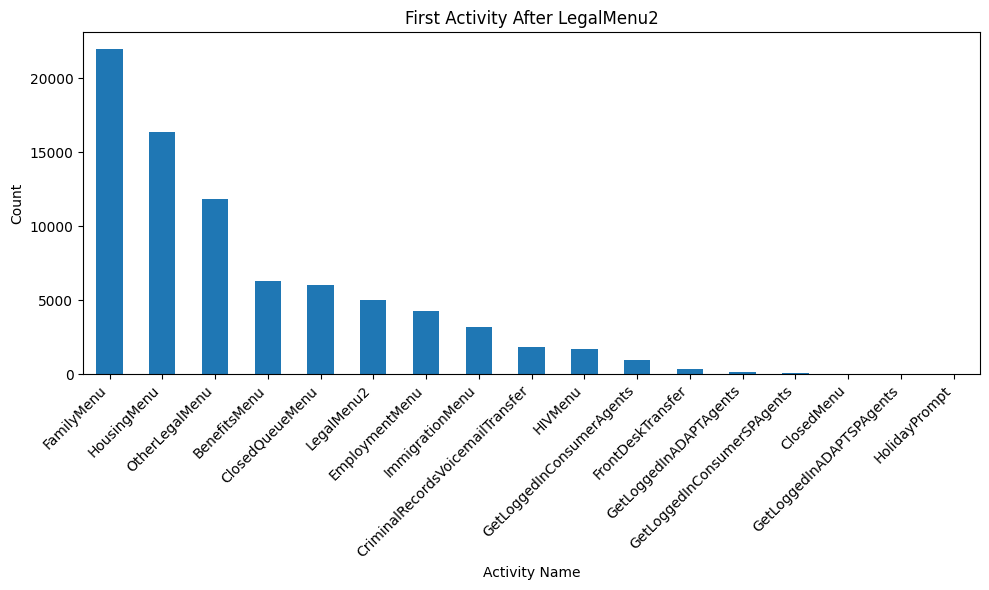

In [21]:
# First Activity for those who pressed key 3
plt.figure(figsize=(10, 6))
activity_counts.plot(kind="bar")
plt.title("First Activity After LegalMenu2")
plt.xlabel("Activity Name")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

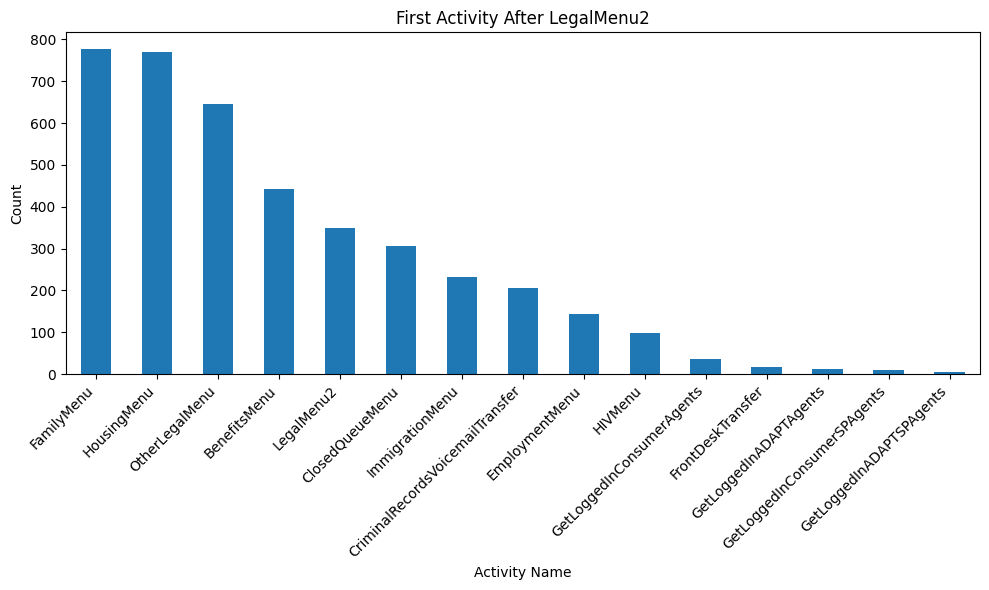

In [22]:
# First Activity for those who pressed key 8
plt.figure(figsize=(10, 6))
activity_other_counts.plot(kind="bar")
plt.title("First Activity After LegalMenu2")
plt.xlabel("Activity Name")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()